In [1]:
import sys
sys.path.insert(0, '/Users/antonk/n/nextsim-tools/python')
from pynextsim.irregular_grid_interpolator import IrregularGridInterpolator

In [2]:
import os
from datetime import datetime, timedelta
import glob
import gc

from tqdm.notebook import tqdm, trange
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.ndimage import minimum_filter, median_filter, gaussian_filter
from scipy.interpolate import RegularGridInterpolator

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from cmocean.cm import ice
from matplotlib.tri import Triangulation

from lmsiage.mesh_file import MeshFile

In [3]:
# read the data
with xr.open_dataset('SAGE_RRDP/s_rrdp_jan21/20200103_N.nc') as ds:
    xc = ds['xc'].values
    yc = ds['yc'].values
    # Create feature names based on the data variables
    feature_names = []
    for v in sorted(ds.variables):
        if v.startswith('ASCAT_') or (v.startswith('AMSR2_') and v.endswith('_M')):
            feature_names.append(v)    
xcg, ycg = np.meshgrid(xc, yc)

with np.load('../sea_ice_age/mesh_arctic_ease_25km_max7.npz') as npz:
    landmask = npz['landmask']
    mask = npz['mask']
    x = npz['xc'] * 1000
    y = npz['yc'][::-1] * 1000
xg, yg = np.meshgrid(x, y)
mask_interpolator = RegularGridInterpolator((y, x), minimum_filter(mask, 5), bounds_error=False, fill_value=0.0)

In [16]:
sia_dir = 'NERSC_arctic25km_sea_ice_age_v2p1/zarr'
mesh_dir = f'{sia_dir}/mesh'
age_dir = f'{sia_dir}/age_da'
MAX_LEN_FRACTIONS = 6
force = False

mesh_files = sorted(glob.glob(f'{mesh_dir}/*/mesh_*.zip'))
age_files = sorted(glob.glob(f'{age_dir}/*/age_*.zip'))
start_file = f'{age_dir}/2019/age_20190915.zip'

not_myi_files = [f for f in age_files if '0915.zip' not in f]
if len(not_myi_files) > 0 and not force:
    start_file = not_myi_files[-1]
start_date = datetime.strptime(os.path.basename(start_file), 'age_%Y%m%d.zip')

end_date = datetime.strptime(os.path.basename(mesh_files[-1]), 'mesh_%Y%m%d.zip')
end_date = datetime(2021, 12, 31)
duration = (end_date - start_date).days
print(start_date, end_date, duration)

2019-09-15 00:00:00 2021-12-31 00:00:00 838


In [27]:
max_mse = 2
tempering_weight = 0.2
min_myi_pred = 15  # minimum MYI concentration to apply DA

for i in trange(duration):
    src_file_date = start_date + timedelta(i)
    dst_file_date = start_date + timedelta(i + 1)
    
    # load previously propagated MYI
    src_age_path = src_file_date.strftime(f'{age_dir}/%Y/age_%Y%m%d.zip')
    src_age = MeshFile(src_age_path)
    src_names = src_age.read_names()
    # select only N most recent fractions, N = MAX_LEN_FRACTIONS
    myi_names = sorted([n for n in src_names if n.startswith('sic') and len(n) > 3], reverse=True)[:MAX_LEN_FRACTIONS][::-1]
    src_myi = src_age.load(myi_names)
    
    # load mesh
    dst_mesh_path = dst_file_date.strftime(f'{mesh_dir}/%Y/mesh_%Y%m%d.zip')
    dst_mesh = MeshFile(dst_mesh_path)
    src2dst, w, ar, sic = dst_mesh.load(['src2dst', 'weights', 'ar', 'sic'], as_dict=False)
    ar[ar == 0] = 0.01

    # propagate all previous MYI
    dst_myi = {}
    for name, c0 in src_myi.items():
        c1 = np.zeros(src2dst[:,1].max()+1)
        np.add.at(c1, src2dst[:,1], c0[src2dst[:,0]] * w)
        c1 /= ar
        c1 = np.clip(c1, 0, 100)
        c1 = np.where(c1 > sic, sic, c1)
        dst_myi[name] = c1


    # Data assimilation
    snapshot_file = f'SAGE_RRDP/s_rrdp_jan21/{dst_file_date.strftime("%Y%m%d")}_N.nc'
    if not os.path.exists(snapshot_file):
        #print(f'Snapshot file not found: {snapshot_file}, skipping DA')
        pass
    elif (dst_file_date.month > 5 and (dst_file_date.month <= 9 and dst_file_date.day < 15)):
        #print(f'Summer month {dst_file_date}, skipping DA')
        pass
    else:
        with xr.open_dataset(snapshot_file) as ds:    
            data = []
            for v in sorted(feature_names):
                if v in ds.variables:
                    data.append(ds[v][0,:,:].values)
        if len(data) < 4:
            print(f'Not enough features ({len(data)}) in snapshot file: {snapshot_file}, skipping DA')
        else:
            # load data for interpolations
            src_mesh_path = src_file_date.strftime(f'{mesh_dir}/%Y/mesh_%Y%m%d.zip')
            src_mesh = MeshFile(src_mesh_path)
            x0_mesh, y0_mesh, t0 = src_mesh.load(['x', 'y', 't'], as_dict=False)
            x1_mesh, y1_mesh, t1 = dst_mesh.load(['x', 'y', 't'], as_dict=False)

            igi1_inv = IrregularGridInterpolator(xcg.flatten(), ycg.flatten(), x1_mesh[t1].mean(axis=1)*1000, y1_mesh[t1].mean(axis=1)*1000)
            data_mesh = []
            for i in range(len(data)):
                data_mesh.append(igi1_inv.interp_field(data[i].flatten()))
            data_mesh = np.array(data_mesh)    
            mask_mesh = mask_interpolator(np.column_stack((y1_mesh[t1].mean(axis=1)*1000, x1_mesh[t1].mean(axis=1)*1000)))                
            mask_mesh = mask_mesh > 0.9
            x = data_mesh[:, mask_mesh].T

            tri0 = Triangulation(x0_mesh, y0_mesh, t0)
            tri1 = Triangulation(x1_mesh, y1_mesh, t1)

            # First guess
            # advect the youngest MYI fraction only
            src_myi_latest_name = sorted(myi_names)[-1]
            src_myi_latest = src_myi[src_myi_latest_name]
            dst_myi_00 = np.zeros(src2dst[:,1].max()+1)
            np.add.at(dst_myi_00, src2dst[:,1], src_myi_latest[src2dst[:,0]] * w)
            dst_myi_00 = dst_myi_00[mask_mesh]

            # Tempering
            for i in range(10):
                regr = RandomForestRegressor(n_estimators=10, max_depth=20, min_samples_split=5, min_samples_leaf=1, n_jobs=-1)

                y = dst_myi_00
                x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8)

                # Create pipeline with StandardScaler and a regressor
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('regressor', regr)
                ])

                pipeline.fit(x_train, y_train)
                y_test_pred = pipeline.predict(x_test)
                r2 = r2_score(y_test, y_test_pred)
                mse = mean_squared_error(y_test, y_test_pred)
                myi0_pred = pipeline.predict(x)

                # Update
                dst_myi_00 = myi0_pred * tempering_weight + dst_myi_00 * (1 - tempering_weight)
                if mse < max_mse:
                    break
            
            if mse < max_mse:
                print(f"{snapshot_file} DA converged: R2={r2:.4f}, MSE={mse:.4f}")
                dst_myi[src_myi_latest_name][mask_mesh] = dst_myi_00
            
            # remove inconsistencies (replace values larger that younger fractions with the younger fraction values)
            normalised_data = {f'sic{dst_file_date.strftime("%Y%m%d")}': sic}
            normalised_data.update(dst_myi)
            sorted_keys = sorted(normalised_data.keys(), reverse=True)
            for i in range(1, len(sorted_keys)):
                excess_idx = normalised_data[sorted_keys[i]] > normalised_data[sorted_keys[i-1]]
                normalised_data[sorted_keys[i]][excess_idx] = normalised_data[sorted_keys[i-1]][excess_idx]
            for myi_name in dst_myi.keys():
                dst_myi[myi_name] = normalised_data[myi_name]
            
    # compute Age and fractions
    src_sic_names = sorted([sic_name for sic_name in dst_myi.keys() if 'sic' in sic_name])
    src_sic = [dst_myi[name] for name in src_sic_names]
    fractions = np.diff(np.array([np.zeros_like(sic)] + src_sic + [sic]), axis=0)
    nfracs = fractions.shape[0]
    if datetime(4, dst_file_date.month, dst_file_date.day) >= datetime(4, 9, 15):
        dst_age_offset = dst_file_date - datetime(dst_file_date.year, 9, 15)
    else:
        dst_age_offset = dst_file_date - datetime(dst_file_date.year-1, 9, 15)
    dst_age_offset = dst_age_offset.days / 365.
    years = np.arange(nfracs, 0, -1)
    years = years - 1 + dst_age_offset
    age = np.sum(fractions * years[None].T, axis=0)/100.
    dst_myi['age'] =  age.astype(np.float32)
    dst_myi['f'] = fractions.astype(np.float32)

    # save next MYI
    dst_age_path = dst_file_date.strftime(f'{age_dir}/%Y/age_%Y%m%d.zip')        
    dst_mf = MeshFile(dst_age_path)
    dst_mf.save(dst_myi, mode='o')


  0%|          | 0/838 [00:00<?, ?it/s]

SAGE_RRDP/s_rrdp_jan21/20190916_N.nc DA converged: R2=0.9989, MSE=1.8452
SAGE_RRDP/s_rrdp_jan21/20190917_N.nc DA converged: R2=0.9991, MSE=1.5163
SAGE_RRDP/s_rrdp_jan21/20190919_N.nc DA converged: R2=0.9989, MSE=1.8401
SAGE_RRDP/s_rrdp_jan21/20190923_N.nc DA converged: R2=0.9990, MSE=1.7130
SAGE_RRDP/s_rrdp_jan21/20190924_N.nc DA converged: R2=0.9989, MSE=1.8660
SAGE_RRDP/s_rrdp_jan21/20190926_N.nc DA converged: R2=0.9990, MSE=1.5818
SAGE_RRDP/s_rrdp_jan21/20190930_N.nc DA converged: R2=0.9990, MSE=1.6236
SAGE_RRDP/s_rrdp_jan21/20191001_N.nc DA converged: R2=0.9991, MSE=1.3468
SAGE_RRDP/s_rrdp_jan21/20191003_N.nc DA converged: R2=0.9987, MSE=1.9704
SAGE_RRDP/s_rrdp_jan21/20191007_N.nc DA converged: R2=0.9989, MSE=1.6457
SAGE_RRDP/s_rrdp_jan21/20191008_N.nc DA converged: R2=0.9989, MSE=1.6581
SAGE_RRDP/s_rrdp_jan21/20191010_N.nc DA converged: R2=0.9987, MSE=1.9492
SAGE_RRDP/s_rrdp_jan21/20191014_N.nc DA converged: R2=0.9988, MSE=1.7572
SAGE_RRDP/s_rrdp_jan21/20191015_N.nc DA converged: 

ValueError: The length of c must match either the number of points or the number of triangles

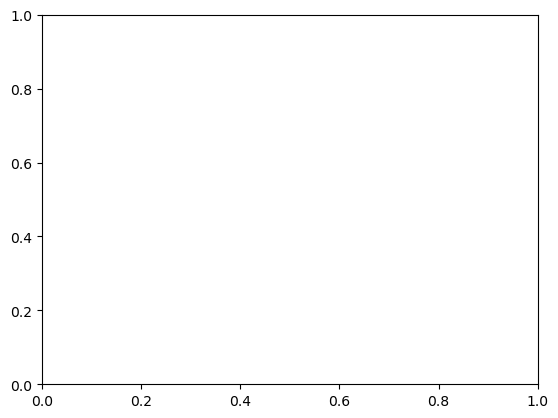

In [28]:
plt.tripcolor(x1_mesh, y1_mesh, t1, dst_myi[src_myi_latest_name])

In [ ]:
myi_name = 'sic20190915'

igi1_inv = IrregularGridInterpolator(xcg.flatten(), ycg.flatten(), x1_mesh[t1].mean(axis=1)*1000, y1_mesh[t1].mean(axis=1)*1000)
data_mesh = []
for i in range(len(data)):
    data_mesh.append(igi1_inv.interp_field(data[i].flatten()))
data_mesh = np.array(data_mesh)    
mask_mesh = mask_interpolator(np.column_stack((y1_mesh[t1].mean(axis=1)*1000, x1_mesh[t1].mean(axis=1)*1000)))                
mask_mesh = mask_mesh > 0.9
x = data_mesh[:, mask_mesh].T

tri0 = Triangulation(x0_mesh, y0_mesh, t0)
tri1 = Triangulation(x1_mesh, y1_mesh, t1)

myi0 = dst_myi_a[myi_name].copy() #+ np.random.normal(0, 3, size=dst_myi_a[myi_name].shape)
myi1 = dst_myi[myi_name]

myi00 = myi0.copy()

In [ ]:
max_mse = 2
w = 0.2 * np.ones(myi00.size)

errors  = []
mses = []
updates = []
myi_upds = []
for i in range(10):
    regr = RandomForestRegressor(n_estimators=10, max_depth=20, min_samples_split=5, min_samples_leaf=1, n_jobs=-1)

    y = myi0[mask_mesh]
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8)

    # Create pipeline with StandardScaler and a regressor
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', regr)
    ])

    pipeline.fit(x_train, y_train)
    y_test_pred = pipeline.predict(x_test)
    r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    mses.append(mse)
    y_pred = pipeline.predict(x)
    myi0_pred = np.full(mask_mesh.shape, np.nan)
    myi0_pred[mask_mesh] = y_pred    

    # overkill: reduce weight where previous updates were large
    if len(myi_upds) > 2:
        myi_uds_std = np.std(myi_upds, axis=0)
        myi_uds_avg = np.mean(myi_upds, axis=0)
        myi_upds_var = np.clip(myi_uds_std / myi_uds_avg, 0, 1)
        myi_upds_var[np.isnan(myi_upds_var)] = 1.0
        #w = w * (1 - myi_upds_var)    

    myi0_upd = myi0_pred * w + myi0 * (1 - w)
    update = np.nanmean(np.abs(myi0_upd - myi0))
    updates.append(update)

    print(f"{snapshot_file} R2={r2:.4f}, MSE={mse:.4f}")

    #plt.plot(y_test, y_test_pred, '.', alpha=0.1)
    #plt.show()

    cmap = ice
    vmax = 90
    #fig, axs = plt.subplots(2, 2, figsize=(7,7), sharey=True, sharex=True)
    #axs.flat[0].tripcolor(tri1, myi0, vmin=0, vmax=vmax, cmap=cmap)
    #axs.flat[0].tripcolor(tri1, myi0, vmin=0, vmax=vmax, cmap=cmap)
    #axs.flat[1].tripcolor(tri1, myi0_upd - myi0, vmin=-5, vmax=5, cmap='coolwarm')
    #axs.flat[2].tripcolor(tri1, myi0_pred, vmin=0, vmax=vmax, cmap=cmap)
    #axs.flat[3].tripcolor(tri1, myi0_pred - myi00, vmin=-5, vmax=5, cmap='coolwarm')
    #plt.tight_layout()

    errors.append(np.nanmean((myi00[mask_mesh] - myi0_upd[mask_mesh])**2)**0.5)
    myi0 = myi0_upd
    myi_upds.append(myi0_upd)
    if mse < max_mse:
        break

In [ ]:
myi_upds_var

In [ ]:
plt.plot(errors, '.-')
plt.plot(mses, '.-')
plt.plot(updates, '.-')


In [ ]:
myi_uds_std = np.std(myi_upds, axis=0)
myi_uds_avg = np.mean(myi_upds, axis=0)
myi_upds_var = myi_uds_std / myi_uds_avg
plt.tripcolor(tri1, w, vmin=0, vmax=1, cmap='jet')

In [ ]:
myi00_plot = myi00.copy()
myi00_plot[np.isnan(myi0_upd)] = np.nan
fig, axs = plt.subplots(2, 2, figsize=(7,7), sharey=True, sharex=True)
axs.flat[0].tripcolor(tri1, myi00_plot, vmin=-5, vmax=vmax, cmap='jet')
axs.flat[1].tripcolor(tri1, myi0_upd - myi0, vmin=-1, vmax=1, cmap='coolwarm')
axs.flat[2].tripcolor(tri1, myi0_upd, vmin=-5, vmax=vmax, cmap='jet')
axs.flat[3].tripcolor(tri1, myi0_upd - myi00, vmin=-5, vmax=5, cmap='coolwarm')
plt.tight_layout()


In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(7,7), sharey=True, sharex=True)
axs.flat[0].tripcolor(tri1, myi00, vmin=0, vmax=vmax, cmap=cmap)
axs.flat[1].tripcolor(tri1, myi0_upd - myi0, vmin=-1, vmax=1, cmap='coolwarm')
axs.flat[2].tripcolor(tri1, myi0_upd, vmin=0, vmax=vmax, cmap=cmap)
axs.flat[3].tripcolor(tri1, myi0_upd - myi00, vmin=-5, vmax=5, cmap='coolwarm')
plt.tight_layout()


In [30]:
year = '2021'
plt_date = f'{year}1216'
age_file_da = f'zarr/age_da/{year}/age_{plt_date}.zip'
age_file = f'zarr/age/{year}/age_{plt_date}.zip'
mesh_file = f'zarr/mesh/{year}/mesh_{plt_date}.zip'

x_mesh, y_mesh, t = MeshFile(mesh_file).load(['x', 'y', 't'], as_dict=False)
myi = MeshFile(age_file).load()
myi_da = MeshFile(age_file_da).load()

with xr.open_dataset(f'SAGE_RRDP/s_rrdp_jan21/{plt_date}_N.nc') as ds:
    NIC_myi_conc = ds['NIC_myi_conc'][0,:,:].values
    AMSR2_TB36_5V_M = ds['AMSR2_TB36.5V_M'][0,:,:].values


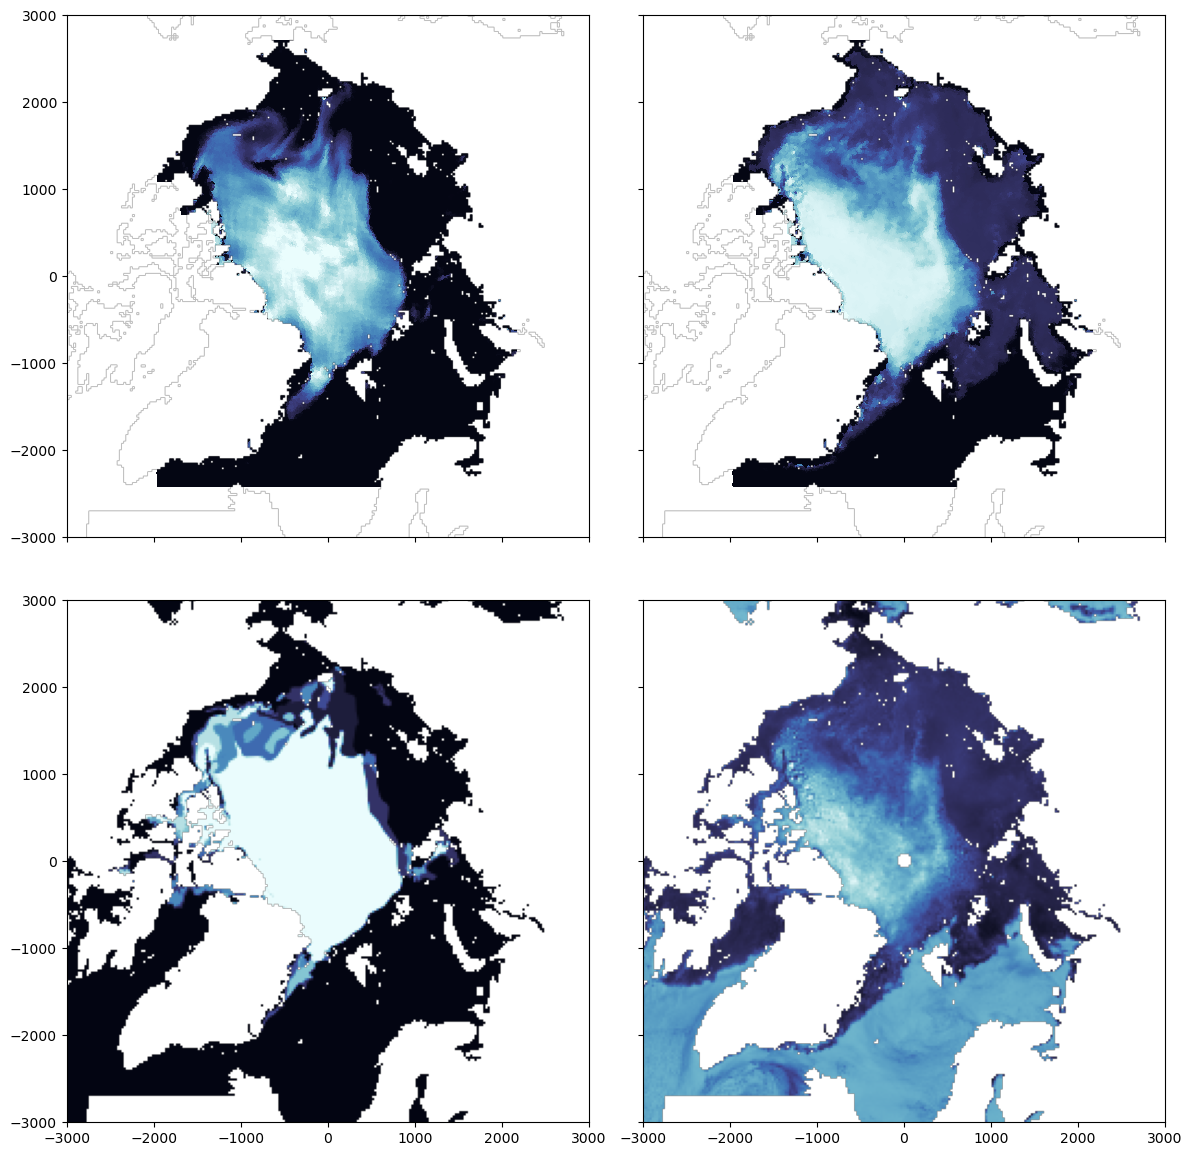

In [31]:
from cmocean.cm import ice

myi_date = '20210915'

AMSR2_TB36_5V_M[np.isnan(NIC_myi_conc)] = np.nan
mask_land = np.ma.masked_array(np.isnan(NIC_myi_conc), mask=np.isfinite(NIC_myi_conc))
cmap = ice
vmax = 90
extent=[xc.min()/1000, xc.max()/1000, yc.min()/1000, yc.max()/1000]
fig, axs = plt.subplots(2, 2, figsize=(12,12), sharey=True, sharex=True)
axs.flat[0].tripcolor(x_mesh, y_mesh, t, myi[f'sic{myi_date}'], vmin=0, vmax=vmax, cmap=cmap, zorder=0)
axs.flat[0].imshow(mask_land, vmin=0, vmax=1, extent=extent, cmap='gray', alpha=1, zorder=1)
axs.flat[1].tripcolor(x_mesh, y_mesh, t, myi_da[f'sic{myi_date}'], vmin=0, vmax=vmax, cmap=cmap)
axs.flat[1].imshow(mask_land, vmin=0, vmax=1, extent=extent, cmap='gray', alpha=1, zorder=1)
axs.flat[2].imshow(NIC_myi_conc, vmin=0, vmax=0.9, extent=extent, cmap=cmap)
axs.flat[3].imshow(-AMSR2_TB36_5V_M, extent=extent, cmap=cmap)
plt.tight_layout()